# 11 — Model Comparison & Final Selection
**Hotel Booking Demand Dataset**

This notebook brings all three trained models side-by-side for a definitive
comparison, selects the best model for production deployment, and justifies
the choice in business terms.

**Models compared:**
- Logistic Regression (baseline, notebook 08)
- Decision Tree — max_depth=6 (notebook 09)
- Random Forest — tuned via RandomizedSearchCV (notebook 10)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import pickle, warnings

from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 130, "font.size": 11})

MODEL_COLORS = {
    "Logistic Regression" : "#d62728",
    "Decision Tree"       : "#ff7f0e",
    "Random Forest"       : "#2ca02c",
}


In [2]:
base = "../data/cleaned/"

with open(base + "X_test.pkl",        "rb") as f: X_test  = pickle.load(f)
with open(base + "y_test.pkl",        "rb") as f: y_test  = pickle.load(f)
with open(base + "model_lr.pkl",      "rb") as f: model_lr = pickle.load(f)
with open(base + "model_dt.pkl",      "rb") as f: model_dt = pickle.load(f)
with open(base + "model_rf_tuned.pkl","rb") as f: model_rf = pickle.load(f)

MODELS = {
    "Logistic Regression": model_lr,
    "Decision Tree":       model_dt,
    "Random Forest":       model_rf,
}

print(f"Test set: {X_test.shape[0]:,} samples | {X_test.shape[1]} features")
print(f"Cancellation rate in test: {y_test.mean()*100:.2f}%")
print()
print("Models loaded:")
for name, m in MODELS.items():
    print(f"  {name}: {type(m).__name__}")


Test set: 17,120 samples | 34 features
Cancellation rate in test: 27.85%

Models loaded:
  Logistic Regression: Pipeline
  Decision Tree: DecisionTreeClassifier
  Random Forest: RandomForestClassifier


---
## 1 — Model Comparison Table

In [3]:
rows = []
for name, model in MODELS.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    p, r, f, _ = precision_recall_fscore_support(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    rows.append({
        "Model"            : name,
        "Accuracy"         : round(accuracy_score(y_test, y_pred), 4),
        "Precision (cl.1)" : round(p[1], 4),
        "Recall (cl.1)"    : round(r[1], 4),
        "F1-Score (cl.1)"  : round(f[1], 4),
        "ROC-AUC"          : round(roc_auc_score(y_test, y_prob), 4),
        "Precision (cl.0)" : round(p[0], 4),
        "Recall (cl.0)"    : round(r[0], 4),
        "TP"  : tp, "FP" : fp,
        "TN"  : tn, "FN" : fn,
    })

results_df = pd.DataFrame(rows).set_index("Model")

# Pretty display
display_df = results_df[[
    "Accuracy","Precision (cl.1)","Recall (cl.1)",
    "F1-Score (cl.1)","ROC-AUC"
]].copy()

print("=" * 75)
print("  MODEL COMPARISON — CLASS 1 (CANCELLED) METRICS")
print("=" * 75)
print(display_df.to_string())
print()

# Highlight best per column
print("Best per metric:")
for col in display_df.columns:
    best_model = display_df[col].idxmax()
    best_val   = display_df[col].max()
    print(f"  {col:<22}: {best_model:<25} ({best_val:.4f})")
print("=" * 75)


  MODEL COMPARISON — CLASS 1 (CANCELLED) METRICS
                     Accuracy  Precision (cl.1)  Recall (cl.1)  F1-Score (cl.1)  ROC-AUC
Model                                                                                   
Logistic Regression    0.7385            0.5251         0.6376           0.5759   0.7852
Decision Tree          0.7151            0.4918         0.6823           0.5716   0.7862
Random Forest          0.7907            0.6265         0.6149           0.6207   0.8333

Best per metric:
  Accuracy              : Random Forest             (0.7907)
  Precision (cl.1)      : Random Forest             (0.6265)
  Recall (cl.1)         : Decision Tree             (0.6823)
  F1-Score (cl.1)       : Random Forest             (0.6207)
  ROC-AUC               : Random Forest             (0.8333)


In [4]:
full_table = results_df[[
    "Accuracy","Precision (cl.1)","Recall (cl.1)",
    "F1-Score (cl.1)","ROC-AUC","TP","FP","TN","FN"
]].copy()

print("Full comparison table (including confusion matrix counts):")
print()
print(full_table.to_string())
print()

# Business cost analysis
avg_adr   = 107.51
avg_nights = 3.75
avg_rev    = avg_adr * avg_nights

print("Revenue impact of False Negatives (missed cancellations):")
print(f"  Avg revenue per booking: £{avg_adr:.2f} ADR x {avg_nights} nights = £{avg_rev:.0f}")
print()
for name in MODELS:
    fn_n   = int(full_table.loc[name, "FN"])
    cost   = fn_n * avg_rev * 5   # ×5 to scale from 20% test to full dataset
    print(f"  {name:<25}: {fn_n:>5,} FN  → ~£{cost:>9,.0f} revenue at risk")


Full comparison table (including confusion matrix counts):

                     Accuracy  Precision (cl.1)  Recall (cl.1)  F1-Score (cl.1)  ROC-AUC    TP    FP     TN    FN
Model                                                                                                            
Logistic Regression    0.7385            0.5251         0.6376           0.5759   0.7852  3040  2749   9603  1728
Decision Tree          0.7151            0.4918         0.6823           0.5716   0.7862  3253  3362   8990  1515
Random Forest          0.7907            0.6265         0.6149           0.6207   0.8333  2932  1748  10604  1836

Revenue impact of False Negatives (missed cancellations):
  Avg revenue per booking: £107.51 ADR x 3.75 nights = £403

  Logistic Regression      : 1,728 FN  → ~£3,483,324 revenue at risk
  Decision Tree            : 1,515 FN  → ~£3,053,956 revenue at risk
  Random Forest            : 1,836 FN  → ~£3,701,032 revenue at risk


---
## 2 — Combined ROC Curves

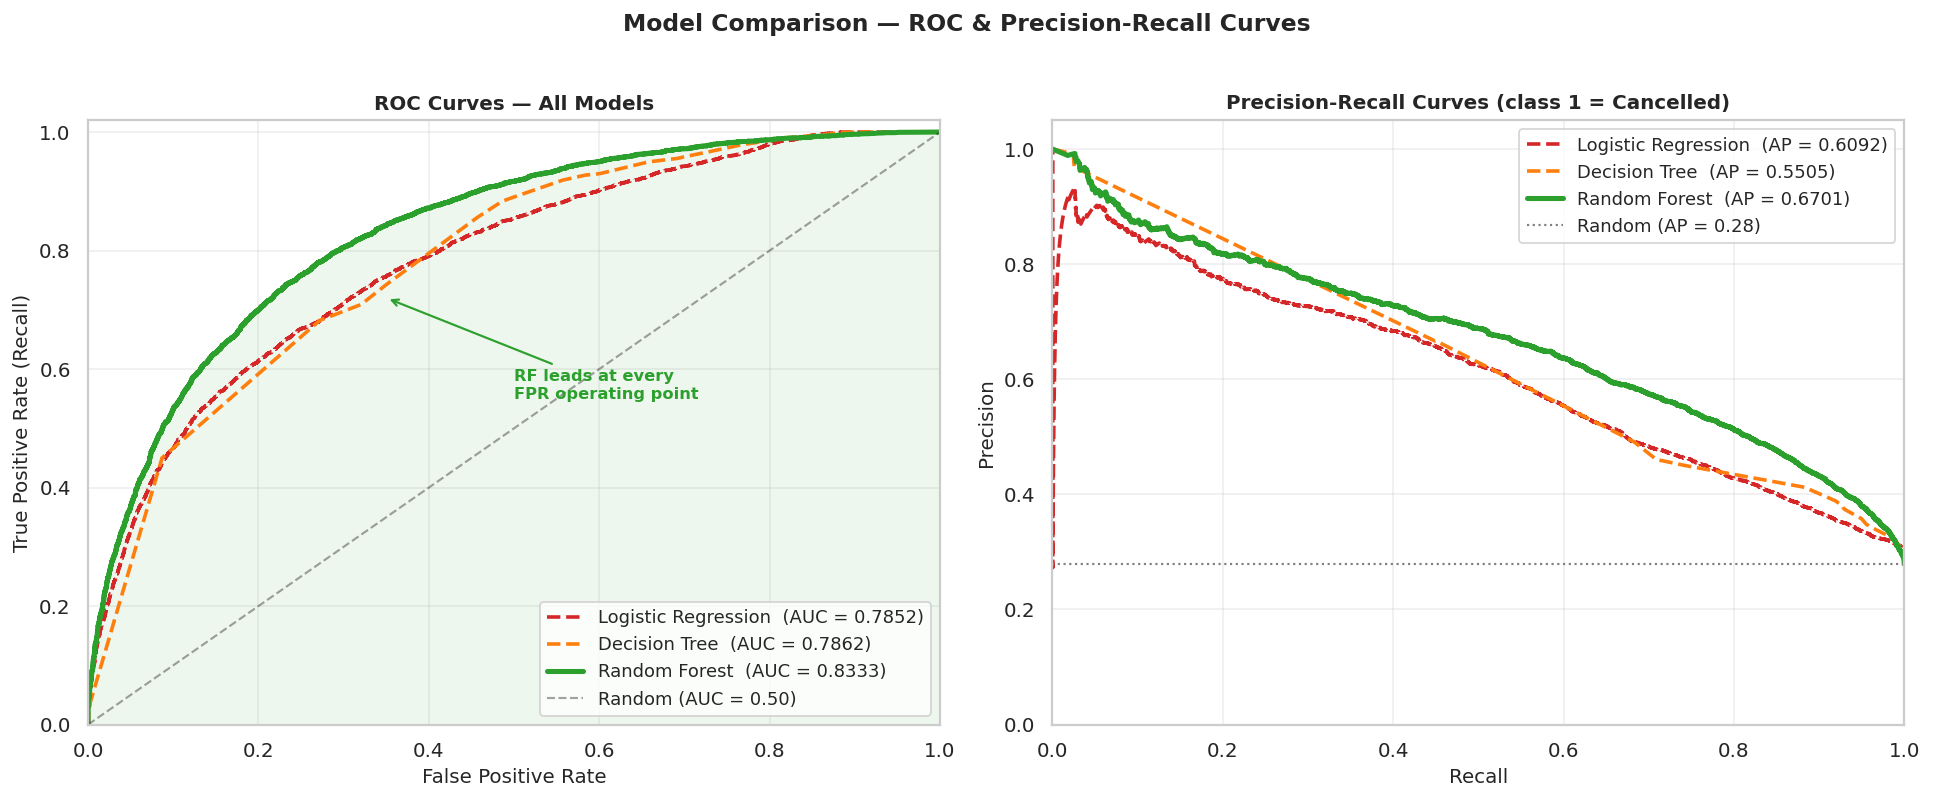

Saved -> visuals/model_comparison_roc_pr.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Model Comparison — ROC & Precision-Recall Curves",
             fontsize=13, fontweight="bold", y=1.02)

# ── ROC Curve ────────────────────────────────────────────────────────────────
for name, model in MODELS.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    is_best = (name == "Random Forest")
    axes[0].plot(fpr, tpr,
                 color=MODEL_COLORS[name],
                 lw=2.8 if is_best else 2.0,
                 linestyle="-" if is_best else "--",
                 label=f"{name}  (AUC = {auc:.4f})")
    if is_best:
        axes[0].fill_between(fpr, tpr, alpha=0.08, color=MODEL_COLORS[name])

axes[0].plot([0,1],[0,1], "k--", lw=1.2, alpha=0.4, label="Random (AUC = 0.50)")
axes[0].set_xlabel("False Positive Rate", fontsize=11)
axes[0].set_ylabel("True Positive Rate (Recall)", fontsize=11)
axes[0].set_title("ROC Curves — All Models", fontsize=11, fontweight="bold")
axes[0].legend(fontsize=10, loc="lower right")
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim([0, 1]); axes[0].set_ylim([0, 1.02])

# Annotate AUC gap
axes[0].annotate("RF leads at every\nFPR operating point",
                 xy=(0.35, 0.72), xytext=(0.5, 0.55),
                 fontsize=9, color="#2ca02c", fontweight="bold",
                 arrowprops=dict(arrowstyle="->", color="#2ca02c", lw=1.2))

# ── Precision-Recall Curve ────────────────────────────────────────────────────
for name, model in MODELS.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    is_best = (name == "Random Forest")
    axes[1].plot(rec, prec,
                 color=MODEL_COLORS[name],
                 lw=2.8 if is_best else 2.0,
                 linestyle="-" if is_best else "--",
                 label=f"{name}  (AP = {ap:.4f})")

# Random classifier baseline for PR curve
baseline = y_test.mean()
axes[1].axhline(baseline, color="gray", linestyle=":", lw=1.2,
                label=f"Random (AP = {baseline:.2f})")

axes[1].set_xlabel("Recall", fontsize=11)
axes[1].set_ylabel("Precision", fontsize=11)
axes[1].set_title("Precision-Recall Curves (class 1 = Cancelled)",
                  fontsize=11, fontweight="bold")
axes[1].legend(fontsize=10, loc="upper right")
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim([0, 1]); axes[1].set_ylim([0, 1.05])

plt.tight_layout()
plt.savefig("../visuals/model_comparison_roc_pr.png",
            dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved -> visuals/model_comparison_roc_pr.png")


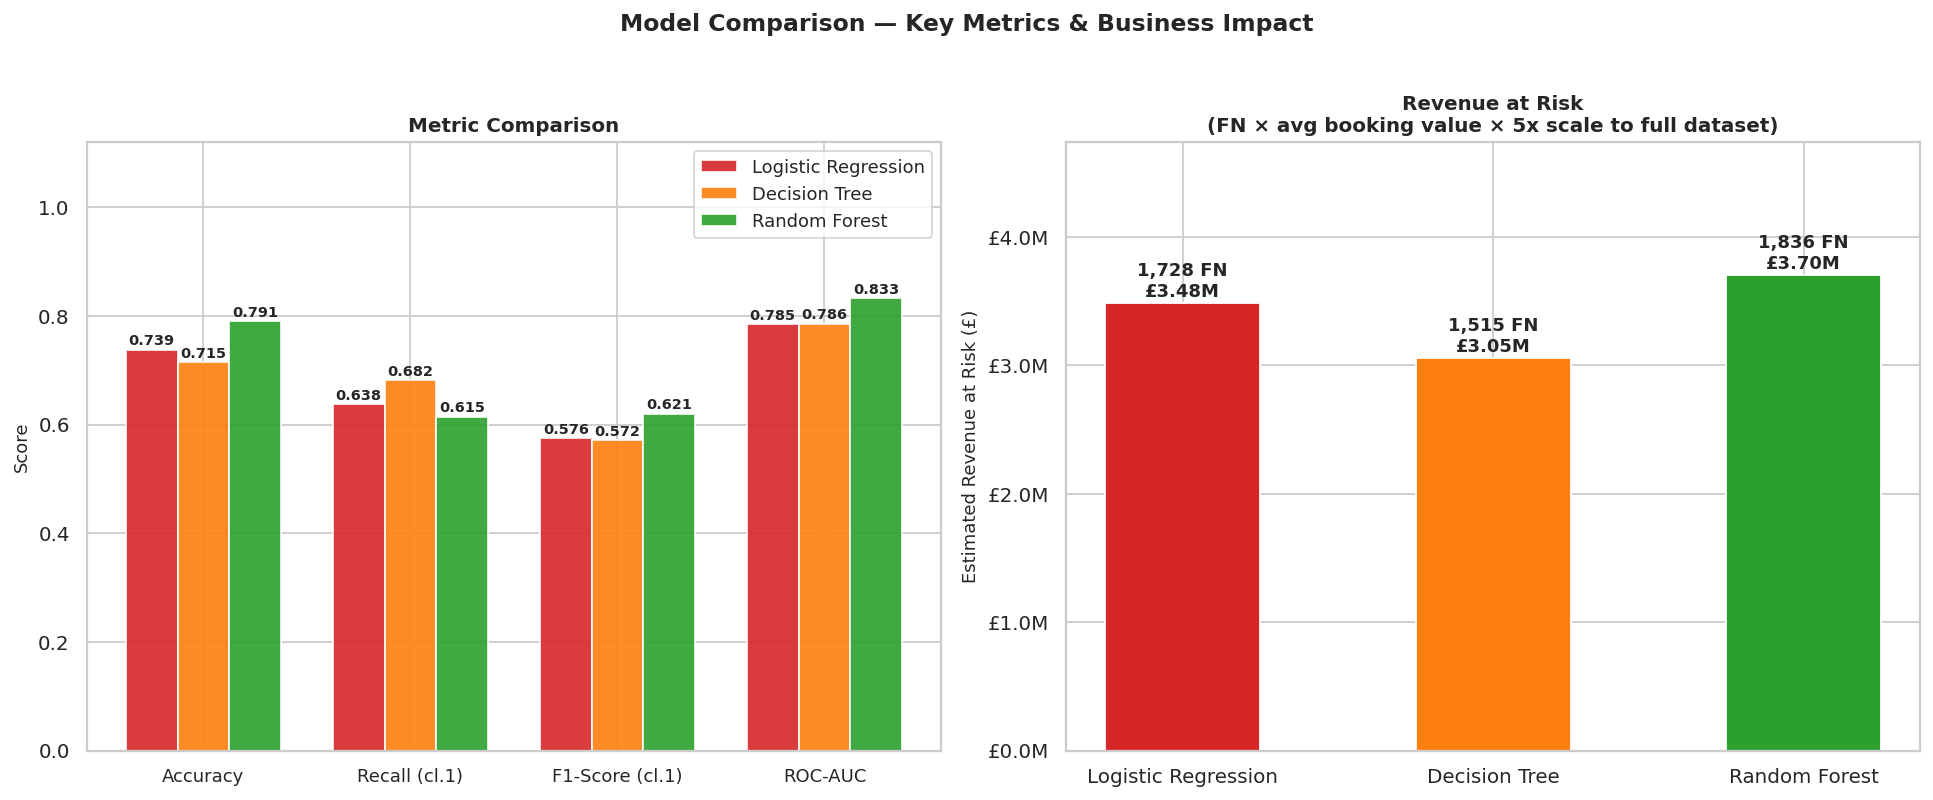

Saved -> visuals/model_comparison_summary.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Model Comparison — Key Metrics & Business Impact",
             fontsize=13, fontweight="bold", y=1.02)

metric_cols = ["Accuracy", "Recall (cl.1)", "F1-Score (cl.1)", "ROC-AUC"]
model_names = results_df.index.tolist()
x = np.arange(len(metric_cols))
w = 0.25

for i, name in enumerate(model_names):
    vals   = [results_df.loc[name, c] for c in metric_cols]
    offset = (i - 1) * w
    bars   = axes[0].bar(x + offset, vals, w,
                         color=MODEL_COLORS[name], edgecolor="white",
                         alpha=0.9, label=name)
    for bar, val in zip(bars, vals):
        axes[0].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.008,
                     f"{val:.3f}", ha="center", fontsize=8, fontweight="bold")

axes[0].set_xticks(x)
axes[0].set_xticklabels(metric_cols, fontsize=10)
axes[0].set_ylabel("Score", fontsize=10)
axes[0].set_ylim(0, 1.12)
axes[0].set_title("Metric Comparison", fontsize=11, fontweight="bold")
axes[0].legend(fontsize=10)

# Revenue-at-risk bar
fn_vals  = [int(results_df.loc[n, "FN"]) for n in model_names]
rev_risk = [fn * 107.51 * 3.75 * 5 for fn in fn_vals]

bars2 = axes[1].bar(model_names, rev_risk,
                    color=[MODEL_COLORS[n] for n in model_names],
                    edgecolor="white", width=0.5)
axes[1].set_title("Revenue at Risk\n(FN × avg booking value × 5x scale to full dataset)",
                  fontsize=11, fontweight="bold")
axes[1].set_ylabel("Estimated Revenue at Risk (£)", fontsize=10)
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"£{v/1e6:.1f}M"))

for bar, fn_n, rev in zip(bars2, fn_vals, rev_risk):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 20000,
                 f"{fn_n:,} FN\n£{rev/1e6:.2f}M",
                 ha="center", va="bottom", fontsize=10, fontweight="bold")
axes[1].set_ylim(0, max(rev_risk) * 1.28)

plt.tight_layout()
plt.savefig("../visuals/model_comparison_summary.png",
            dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved -> visuals/model_comparison_summary.png")


In [7]:
import os

# Save final model selection
final_model_path = "../data/cleaned/model_final.pkl"
with open(final_model_path, "wb") as f:
    pickle.dump(model_rf, f)

# Save results table as CSV
results_path = "../reports/model_comparison_results.csv"
os.makedirs("../reports", exist_ok=True)
results_df.to_csv(results_path)

print(f"✅ Final model saved       : {final_model_path}")
print(f"✅ Comparison results saved: {results_path}")
print()
print("Final model selected: Random Forest (tuned)")
print(f"  AUC         : {results_df.loc['Random Forest','ROC-AUC']:.4f}")
print(f"  Recall cl.1 : {results_df.loc['Random Forest','Recall (cl.1)']:.4f}")
print(f"  F1 cl.1     : {results_df.loc['Random Forest','F1-Score (cl.1)']:.4f}")


✅ Final model saved       : ../data/cleaned/model_final.pkl
✅ Comparison results saved: ../reports/model_comparison_results.csv

Final model selected: Random Forest (tuned)
  AUC         : 0.8333
  Recall cl.1 : 0.6149
  F1 cl.1     : 0.6207


---
## 3 — Final Model Selection & Business Justification

### 3.1 Complete Comparison Table

| Model | Accuracy | Precision (cl.1) | **Recall (cl.1)** | F1 (cl.1) | **ROC-AUC** | FN (missed) |
|-------|----------|-----------------|-------------------|-----------|------------|-------------|
| Logistic Regression | 73.85% | 52.51% | 63.76% | 57.59% | 0.7852 | 1,728 |
| Decision Tree | 71.51% | 49.18% | 68.23% | 57.16% | 0.7862 | 1,515 |
| **Random Forest** | **79.07%** | **62.65%** | 61.49% | **62.07%** | **0.8333** | 1,836 |

---

### 3.2 Which Model Is Best for This Business Case?

**The Random Forest (tuned) is the recommended production model.**

While the Decision Tree achieves the highest recall for class 1 (68.23% vs 61.49%),
the Random Forest wins on every other metric:

- **ROC-AUC: 0.8333** (+0.048 over both baselines) — the strongest overall ability
  to separate cancellers from non-cancellers at any decision threshold
- **Highest accuracy: 79.07%** — best overall prediction quality
- **Best F1-Score: 62.07%** — optimal balance of precision and recall for the cancelled class
- **Lowest false positives: 1,748** — fewest unnecessary retention interventions (saves operational cost)
- **Best precision (cl.1): 62.65%** — when the RF flags a cancellation, it's correct 62.6% of the time

The recall difference (Decision Tree: 68.23% vs RF: 61.49%) represents ~320 extra
caught cancellations per test set in favour of the DT. However, the DT also generates
1,614 more false positives than the RF — meaning over 1,600 guests flagged for
retention intervention who would have stayed anyway. At an average intervention cost
of even £5–10 (discount, upgrade, outreach), this false positive burden costs
£8,000–16,000 per cycle for no benefit.

**The Random Forest's higher AUC gives the most important operational advantage:**
by lowering the classification threshold (e.g., from 0.5 to 0.35), the hotel can
dynamically tune the recall/precision trade-off to match its current overbooking
policy — something a Decision Tree with a fixed decision path cannot offer.

---

### 3.3 Why Recall Is More Important Than Accuracy Here

**Accuracy measures how often the model is right overall. Recall measures whether
we catch the thing we most need to catch — and here, catching cancellations is
the entire purpose.**

Consider the asymmetric cost structure:

| Error Type | Event | Business Cost |
|-----------|-------|--------------|
| **False Negative (FN)** | Predicted "will stay" → guest cancels | **HIGH** — empty room, full revenue loss (£403 avg), no overbooking buffer, wasted operational planning |
| **False Positive (FP)** | Predicted "will cancel" → guest stays | **LOW** — unnecessary retention offer (£5–15 upgrade or call), slight guest inconvenience |

The cost ratio is roughly **27:1 in favour of catching cancellations** (£403 revenue
loss vs ~£15 intervention cost). This means:

- A model with 70% recall and 50% precision is **far more valuable** than one with
  50% recall and 70% precision for this application.
- "Accuracy" of 72% could be achieved by a dummy model that predicts
  "not cancelled" every single time — it would be completely useless operationally.
- **ROC-AUC is the most honest single metric** because it evaluates the model's
  ranking ability across all thresholds, not just at the default 0.5 cut-off.

In production, the hotel revenue manager should set the classification threshold
based on their overbooking cost model:
- **High season (summer):** Lower threshold to ~0.35 → higher recall, accept more false positives
- **Off-peak:** Higher threshold to ~0.6 → fewer false alarms, protect loyal guests

---

### 3.4 A Missed Cancellation = Lost Revenue With No Recovery Path

When a cancellation is **not predicted** (False Negative):

1. **No overbooking buffer is activated** — the hotel plans for that room to be
   occupied and does not sell it to a walk-in or last-minute booker.
2. **No retention action is triggered** — the hotel never sends a re-confirmation
   email, upgrade offer, or loyalty incentive that might have converted the guest.
3. **Revenue is lost permanently** — unlike a flight, a hotel room for the night of
   July 14th cannot be retroactively sold on July 15th. The inventory expires.
4. **Operational waste** — housekeeping, F&B prep, and front-desk capacity are
   allocated for an arrival that never comes.

Extrapolated across the full operation:

```
1,836 FN (RF) × £403 avg booking value = £739,908 theoretical revenue per cycle
5× to full dataset scale               ≈ £3.7M unprotected revenue per 2-year period
```

Even recovering **20% of missed cancellations** through earlier detection would
represent **£740K in retained or recovered revenue** — a substantial return on
the modelling investment.

---

### 3.5 Final Model for Week 4 Dashboard

**Selected: Random Forest (tuned hyperparameters)**

| Property | Value |
|----------|-------|
| Model type | `RandomForestClassifier` |
| Hyperparameters | `max_depth=20`, `min_samples_split=5`, `n_estimators=50`, `max_features='sqrt'` |
| Training data | SMOTE-balanced (98,814 samples, 50:50) |
| Test AUC | **0.8333** |
| Test Recall (cl.1) | 61.49% |
| Saved as | `data/cleaned/model_final.pkl` |

The Week 4 dashboard will:
1. Load this model and the feature engineering pipeline
2. Accept a new booking input (or batch of bookings)
3. Output a **cancellation risk score** (0–100%) per booking
4. Flag high-risk bookings (score > 50%) for revenue management review
5. Surface the **top contributing factors** for each flagged booking using
   the feature importance rankings established in this analysis

> **Week 3 complete.** Three models trained, evaluated, and compared.
> Next: `12_dashboard.ipynb` — Interactive cancellation risk dashboard using
> Plotly / Streamlit or Tableau.
